In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pradyu10/test-image/accident.jpg
/kaggle/input/datasets/pradyu10/test-image2/another_accident.jpg
/kaggle/input/datasets/pradyu10/data-yaml-fold/data.yaml


In [2]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.0 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

Loading the datasets

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="MH5ETFerg8dWFCjb8PAR")
project1 = rf.workspace("yolo-and-car-accident-detection-xaltb").project("accident-detection-77mha")
version1 = project1.version(2)
dataset1 = version1.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Accident-Detection-2 in yolov11:: 100%|██████████| 1172/1172 [00:00<00:00, 8599.61it/s]


In [4]:
project2 = rf.workspace("traffic-ai-8xnmy").project("car-fire-yssjr")
version2 = project2.version(1)
dataset2 = version2.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-fire-1 in yolov11:: 100%|██████████| 174/174 [00:00<00:00, 9228.63it/s]


In [5]:
pwd

'/kaggle/working'

Dataset count

In [6]:
# 1st dataset
print("Accident-Detection-2")
import os

images_folder = "/kaggle/working/Accident-Detection-2/train/images"          
num_images = len(os.listdir(images_folder))

labels_folder = "/kaggle/working/Accident-Detection-2/train/labels"
num_labels = len(os.listdir(labels_folder))

images_folder_test = "/kaggle/working/Accident-Detection-2/test/images"
num_images_test= len(os.listdir(images_folder_test))

labels_folder_test = "/kaggle/working/Accident-Detection-2/test/labels"
num_labels_test = len(os.listdir(labels_folder_test))

images_folder_val = "/kaggle/working/Accident-Detection-2/valid/images"
num_images_val= len(os.listdir(images_folder_val))

labels_folder_val = "/kaggle/working/Accident-Detection-2/valid/labels"
num_labels_val = len(os.listdir(labels_folder_val))

print(f"Number of files in train/images/: {num_images}")
print(f"Number of files in train/labels/: {num_labels}")

print(f"Number of files in val/images/: {num_images_val}")
print(f"Number of files in val/labels/: {num_labels_val}")

print(f"Number of files in test/images/: {num_images_test}")
print(f"Number of files in test/labels/: {num_labels_test}")

Accident-Detection-2
Number of files in train/images/: 373
Number of files in train/labels/: 373
Number of files in val/images/: 77
Number of files in val/labels/: 77
Number of files in test/images/: 130
Number of files in test/labels/: 130


In [7]:
# 2nd dataset
print("Car-fire-1")
images_folder = "/kaggle/working/Car-fire-1/train/images"          
num_images = len(os.listdir(images_folder))

labels_folder = "/kaggle/working/Car-fire-1/train/labels"
num_labels = len(os.listdir(labels_folder))

images_folder_test = "/kaggle/working/Car-fire-1/test/images"
num_images_test= len(os.listdir(images_folder_test))

labels_folder_test = "/kaggle/working/Car-fire-1/test/labels"
num_labels_test = len(os.listdir(labels_folder_test))

images_folder_val = "/kaggle/working/Car-fire-1/valid/images"
num_images_val= len(os.listdir(images_folder_val))

labels_folder_val = "/kaggle/working/Car-fire-1/valid/labels"
num_labels_val = len(os.listdir(labels_folder_val))

print(f"Number of files in train/images/: {num_images}")
print(f"Number of files in train/labels/: {num_labels}")

print(f"Number of files in val/images/: {num_images_val}")
print(f"Number of files in val/labels/: {num_labels_val}")

print(f"Number of files in test/images/: {num_images_test}")
print(f"Number of files in test/labels/: {num_labels_test}")

Car-fire-1
Number of files in train/images/: 65
Number of files in train/labels/: 65
Number of files in val/images/: 12
Number of files in val/labels/: 12
Number of files in test/images/: 4
Number of files in test/labels/: 4


Checking the labels

In [8]:
import os
from collections import Counter

class_names = {
    0: "Accident",
    1: "Car Fire"
}

def count_labels(train_labels_dir):

    if not os.path.exists(train_labels_dir):
        print("Folder not found →", train_labels_dir)
        return

    class_counts = Counter()
    label_files = [f for f in os.listdir(train_labels_dir) if f.lower().endswith('.txt')]
    
    print(f"\nFound {len(label_files)} label files in {train_labels_dir}\n")
    
    for filename in label_files:
        path = os.path.join(train_labels_dir, filename)
        try:
            with open(path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        parts = line.split()
                        if parts and parts[0].isdigit():
                            class_id = int(parts[0])
                            class_counts[class_id] += 1
        except Exception as e:
            print(f"Error in {filename}: {e}")
    
    if class_counts:
        print("Class distribution:")
        for cls, count in sorted(class_counts.items()):
            class_name = class_names.get(cls, f"Unknown ({cls})")
            print(f"  Class {cls:2d} ({class_name:10s}) : {count:5d} instances")
        
        total = sum(class_counts.values())
        print(f"\nTotal bounding boxes / instances : {total}")
        print(f"Average objects per image         : {total / len(label_files):.2f}")
    else:
        print("No valid labels found in any .txt file")

count_labels("/kaggle/working/Car-fire-1/train/labels")
count_labels("/kaggle/working/Accident-Detection-2/train/labels")


Found 65 label files in /kaggle/working/Car-fire-1/train/labels

Class distribution:
  Class  0 (Accident  ) :    65 instances

Total bounding boxes / instances : 65
Average objects per image         : 1.00

Found 373 label files in /kaggle/working/Accident-Detection-2/train/labels

Class distribution:
  Class  0 (Accident  ) :   320 instances

Total bounding boxes / instances : 320
Average objects per image         : 0.86


Creating a combined dataset (folder structure alone)

In [9]:
from pathlib import Path
import os

root = Path("/kaggle/working")

datasets = {
    "accident":root/"Accident-Detection-2",
    "carfire": root/"Car-fire-1"
}

missing_labels = []
empty_or_invalid = []
total_images = 0
total_valid = 0

for name, ds_root in datasets.items():
    for split in ["train", "valid", "test"]:
        img_dir = ds_root / split / "images"
        lbl_dir = ds_root / split / "labels"
        
        if not img_dir.exists():
            continue
            
        for img_p in img_dir.iterdir():
            if img_p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue
                
            total_images += 1
            lbl_p = lbl_dir / (img_p.stem + ".txt")
            
            if not lbl_p.exists():
                missing_labels.append(str(img_p))
                continue
                
            
            valid_lines = 0
            try:
                with open(lbl_p, "r", encoding="utf-8") as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            parts = line.split()
                            if len(parts) >= 5 and parts[0].isdigit():
                                valid_lines += 1
            except:
                pass 
                
            if valid_lines == 0:
                empty_or_invalid.append(str(img_p))
            else:
                total_valid += 1

print(f"Total images scanned: {total_images}")
print(f"Valid pairs kept   : {total_valid}")
print(f"Missing labels     : {len(missing_labels)}")
print(f"Empty/invalid labels: {len(empty_or_invalid)}")

if missing_labels:
    print("\nFirst 10 missing labels:")
    for p in missing_labels[:10]:
        print("  ", p)

if empty_or_invalid:
    print("\nFirst 10 empty/invalid:")
    for p in empty_or_invalid[:10]:
        print("  ", p)

Total images scanned: 661
Valid pairs kept   : 546
Missing labels     : 0
Empty/invalid labels: 115

First 10 empty/invalid:
   /kaggle/working/Accident-Detection-2/train/images/severityV2_7_jpg.rf.2d330a3d0aad1cb8bd7d0ff6fd8c61ee.jpg
   /kaggle/working/Accident-Detection-2/train/images/severityV4_21_jpg.rf.774fa45ecc893d1983722b1cf5f659c8.jpg
   /kaggle/working/Accident-Detection-2/train/images/accidentFrame4158_jpg.rf.e827cbf2423978fbfdd370a69943821f.jpg
   /kaggle/working/Accident-Detection-2/train/images/severityV4_85_jpg.rf.58ae0d0651a004b7ec7e90295651dea2.jpg
   /kaggle/working/Accident-Detection-2/train/images/Severity_Detect_V18_jpg.rf.f7b2341e2ced7e019b0a7d426b5c6871.jpg
   /kaggle/working/Accident-Detection-2/train/images/accidentFrame4161_jpg.rf.13f9252fd78869fbf8aebbeeeef0b5a3.jpg
   /kaggle/working/Accident-Detection-2/train/images/severityV4_21_jpg.rf.5a1ff3dc1f42dc7d0c8411ce3543d06c.jpg
   /kaggle/working/Accident-Detection-2/train/images/severityV4_79_jpg.rf.bac1f61bcfd

In [10]:
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict


root = Path("/kaggle/working")

datasets = {
    "accident":root/"Accident-Detection-2",   # → class 0
    "carfire": root/"Car-fire-1"              # → class 1
}

output_dir = root/"final_combined"

train_img_dir = output_dir/"train"/"images"
train_lbl_dir = output_dir/"train"/"labels"
val_img_dir   = output_dir/"val"/"images"
val_lbl_dir   = output_dir/"val"/"labels"

for d in [train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir]:
    d.mkdir(parents=True, exist_ok=True)


pairs = []   # (img_path, label_path, new_class)

for name, ds_root in datasets.items():

    new_class = 0 if name == "accident" else 1

    for split_name in ["train", "valid", "test"]:

        img_folder = ds_root / split_name / "images"
        lbl_folder = ds_root / split_name / "labels"

        if not img_folder.exists() or not lbl_folder.exists():
            print(f"Skipping missing: {img_folder}")
            continue

        for img_p in img_folder.glob("*"):

            if img_p.suffix.lower() in {".jpg", ".jpeg", ".png"}:

                lbl_p = lbl_folder / (img_p.stem + ".txt")

                if not lbl_p.exists():
                    print(f"Missing label: {lbl_p}")
                    continue

                # Read & remap labels
                corrected_lines = []

                with open(lbl_p, "r") as f:
                    for line in f:
                        line = line.strip()
                        if not line:
                            continue

                        parts = line.split()

                        if len(parts) < 5 or not parts[0].isdigit():
                            continue  # skip invalid lines

                        cls = int(parts[0])

                        # Remap original class 0
                        if cls == 0:
                            parts[0] = str(new_class)

                        corrected_lines.append(" ".join(parts))

                if not corrected_lines:
                    print(f"Empty after filtering: {lbl_p}")
                    continue

                # Write corrected label temporarily
                temp_lbl = output_dir / f"temp_{img_p.stem}_{name}.txt"

                with open(temp_lbl, "w") as f:
                    f.write("\n".join(corrected_lines) + "\n")

                pairs.append((img_p, temp_lbl, new_class))

print(f"\nCollected {len(pairs)} valid image-label pairs\n")

#  Step 2: Shuffle + 80/20 split 
random.seed(42)
random.shuffle(pairs)

n_total = len(pairs)
n_train = int(n_total * 0.80)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:]

print(f"→ Train: {len(train_pairs)}  ({len(train_pairs)/n_total:.1%})")
print(f"→ Val:   {len(val_pairs)}    ({len(val_pairs)/n_total:.1%})")

#  Step 3: Copy files 
def copy_pair(img_src, lbl_src, img_dest_dir, lbl_dest_dir):
    shutil.copy(img_src, img_dest_dir / img_src.name)
    shutil.copy(lbl_src, lbl_dest_dir / (img_src.stem + ".txt"))

print("Copying train...")
for img, lbl, _ in train_pairs:
    copy_pair(img, lbl, train_img_dir, train_lbl_dir)

print("Copying val...")
for img, lbl, _ in val_pairs:
    copy_pair(img, lbl, val_img_dir, val_lbl_dir)

# Clean up temp files
for p in output_dir.glob("temp_*.txt"):
    try:
        p.unlink()
    except:
        pass

print("\nCopy finished.")

Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/severityV2_7_jpg.rf.2d330a3d0aad1cb8bd7d0ff6fd8c61ee.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/severityV4_21_jpg.rf.774fa45ecc893d1983722b1cf5f659c8.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/accidentFrame4158_jpg.rf.e827cbf2423978fbfdd370a69943821f.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/severityV4_85_jpg.rf.58ae0d0651a004b7ec7e90295651dea2.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/Severity_Detect_V18_jpg.rf.f7b2341e2ced7e019b0a7d426b5c6871.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/accidentFrame4161_jpg.rf.13f9252fd78869fbf8aebbeeeef0b5a3.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labels/severityV4_21_jpg.rf.5a1ff3dc1f42dc7d0c8411ce3543d06c.txt
Empty after filtering: /kaggle/working/Accident-Detection-2/train/labe

Found 134 problematic label files total

Label file: /kaggle/working/Accident-Detection-2/test/labels/test10_12_jpg.rf.9bc524b8d7d05a427b0d81c217987d88.txt
Content preview:
<empty file>
Image: /kaggle/working/Accident-Detection-2/test/images/test10_12_jpg.rf.9bc524b8d7d05a427b0d81c217987d88.jpg


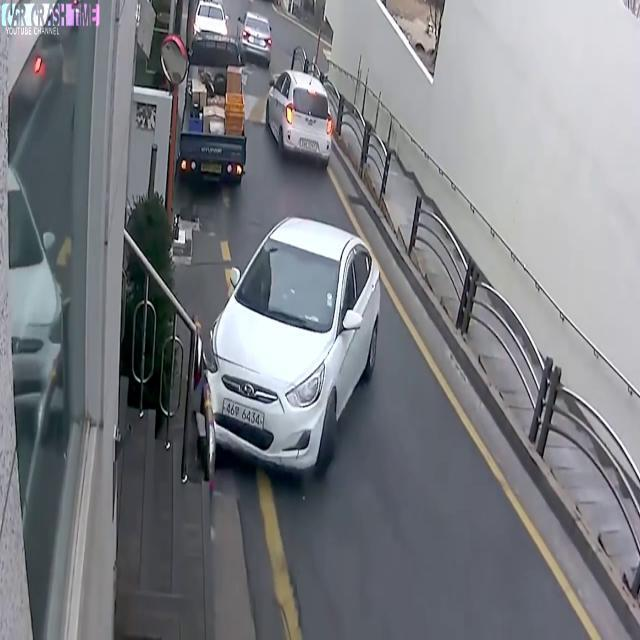


Label file: /kaggle/working/Accident-Detection-2/test/labels/images-11_jpg.rf.44e335f74ac6c97e347f1d5102798731.txt
Content preview:
0 0.5359375 0.521875 0.8203125 0.8875
Image: /kaggle/working/Accident-Detection-2/test/images/images-11_jpg.rf.44e335f74ac6c97e347f1d5102798731.jpg


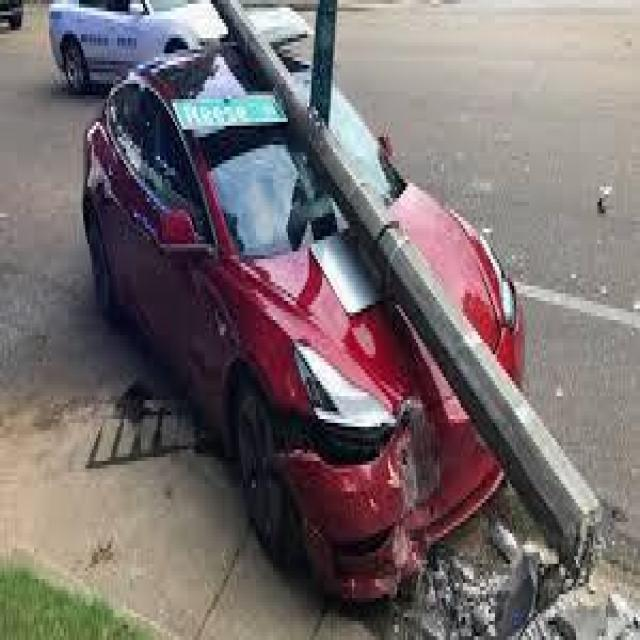


Label file: /kaggle/working/Accident-Detection-2/test/labels/test17_16_jpg.rf.6a67cab68d5f60b402db9ac0c1c9f22f.txt
Content preview:
0 0.371875 0.35234375 0.19375 0.2109375
Image: /kaggle/working/Accident-Detection-2/test/images/test17_16_jpg.rf.6a67cab68d5f60b402db9ac0c1c9f22f.jpg


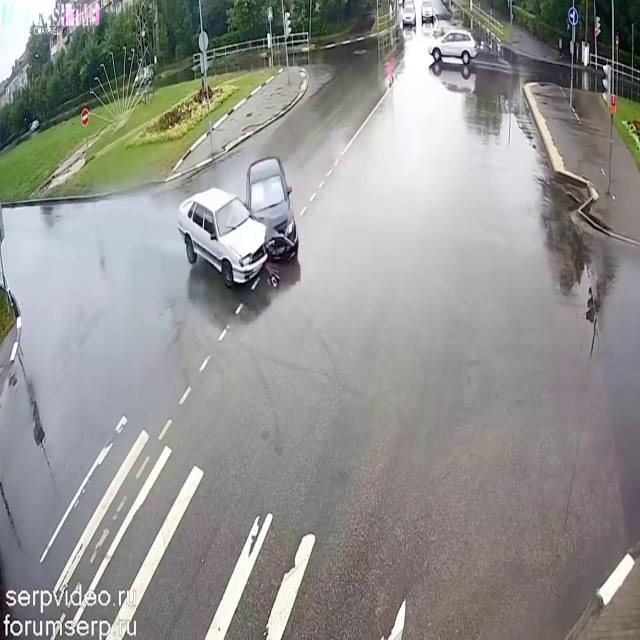


Label file: /kaggle/working/Accident-Detection-2/test/labels/test17_16_jpg.rf.ee66e07d4e9936239124a4ac5cb75cee.txt
Content preview:
0 0.371875 0.3421875 0.1890625 0.2
Image: /kaggle/working/Accident-Detection-2/test/images/test17_16_jpg.rf.ee66e07d4e9936239124a4ac5cb75cee.jpg


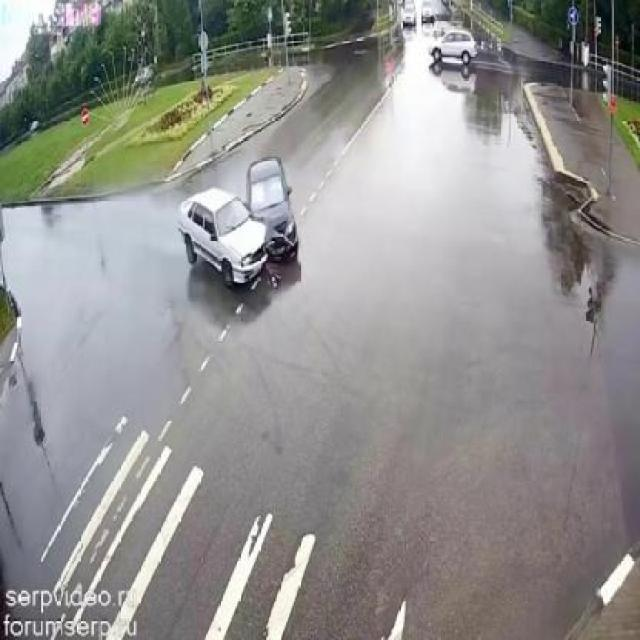


Label file: /kaggle/working/Accident-Detection-2/test/labels/test27_20_jpg.rf.c787287e94174b60b2da9a28df692aa2.txt
Content preview:
<empty file>
Image: /kaggle/working/Accident-Detection-2/test/images/test27_20_jpg.rf.c787287e94174b60b2da9a28df692aa2.jpg


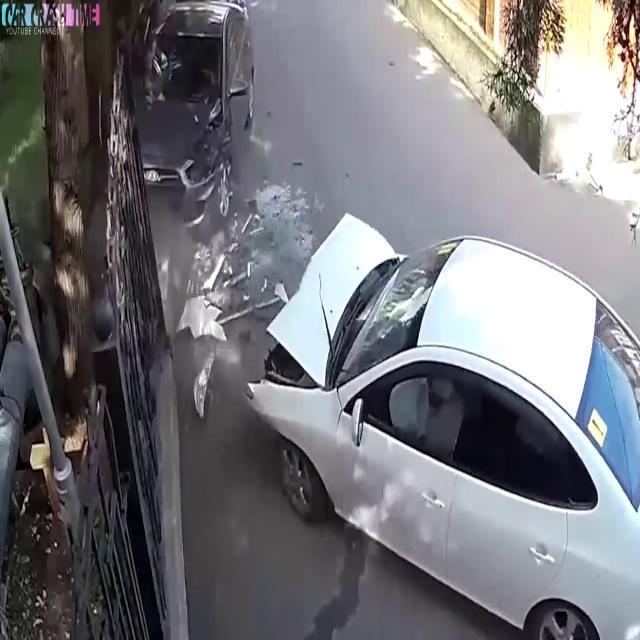


Label file: /kaggle/working/Accident-Detection-2/test/labels/test16_20_jpg.rf.5b23598ecc61cec2dc8351797812d9aa.txt
Content preview:
0 0.61171875 0.55 0.4109375 0.403125
Image: /kaggle/working/Accident-Detection-2/test/images/test16_20_jpg.rf.5b23598ecc61cec2dc8351797812d9aa.jpg


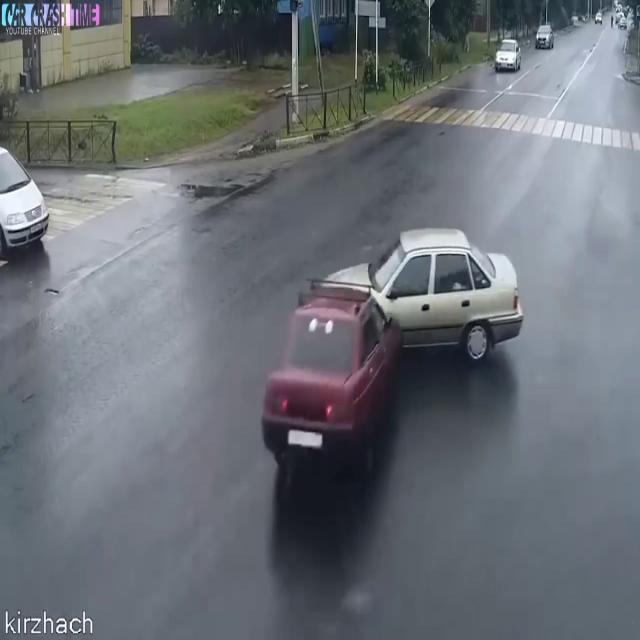


Label file: /kaggle/working/Accident-Detection-2/test/labels/test17_19_jpg.rf.dbb3697b60aa185c33d7d1c5eabf6651.txt
Content preview:
0 0.5 0.49921875 0.23125 0.3890625
Image: /kaggle/working/Accident-Detection-2/test/images/test17_19_jpg.rf.dbb3697b60aa185c33d7d1c5eabf6651.jpg


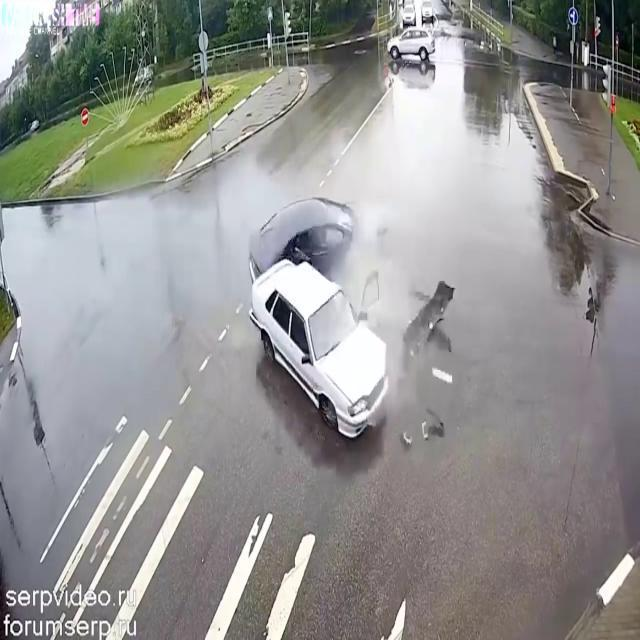


Label file: /kaggle/working/Accident-Detection-2/test/labels/traffic_img497_jpg.rf.348917c38b69d32dd7c4c19716ecdbb8.txt
Content preview:
0 0.465625 0.3125 0.2390625 0.16875
Image: /kaggle/working/Accident-Detection-2/test/images/traffic_img497_jpg.rf.348917c38b69d32dd7c4c19716ecdbb8.jpg


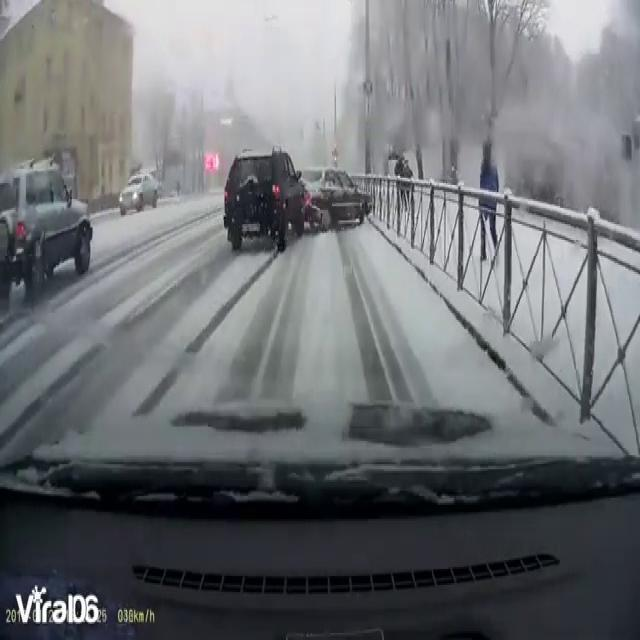


Label file: /kaggle/working/Accident-Detection-2/test/labels/severity_V139_jpg.rf.385818327dd3650476399695630f160d.txt
Content preview:
0 0.5015625 0.50234375 0.996875 0.9953125
Image: /kaggle/working/Accident-Detection-2/test/images/severity_V139_jpg.rf.385818327dd3650476399695630f160d.jpg


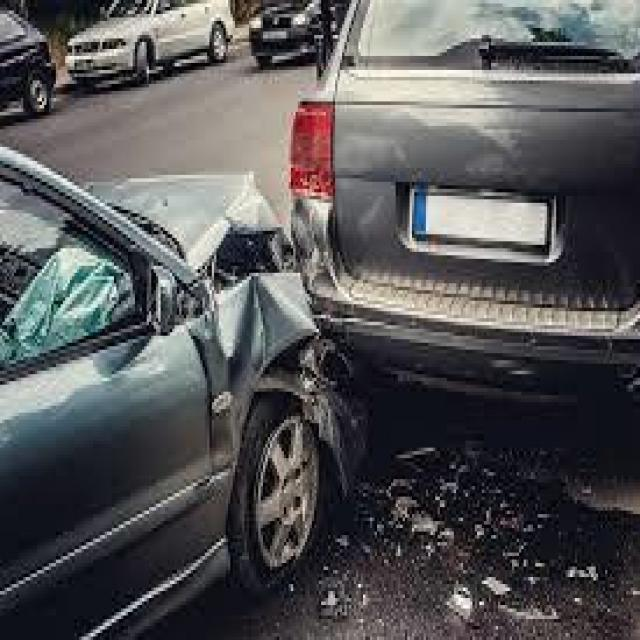


Label file: /kaggle/working/Accident-Detection-2/test/labels/acc453_jpg.rf.faa2a4471bf20e8cf8144c405fdae434.txt
Content preview:
0 0.30703125 0.7390625 0.4046875 0.371875
Image: /kaggle/working/Accident-Detection-2/test/images/acc453_jpg.rf.faa2a4471bf20e8cf8144c405fdae434.jpg


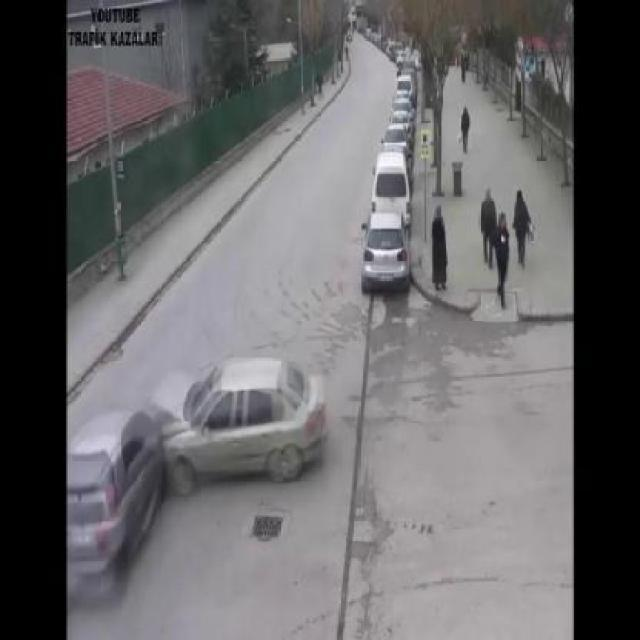

In [11]:
from pathlib import Path
from IPython.display import Image, display
import textwrap


DATA_ROOT = Path("/kaggle/working")


problematic_labels = []


for folder in [
    DATA_ROOT / "Accident-Detection-2" / "test" / "labels",
    DATA_ROOT / "Car-fire-1" / "test" / "labels",
]:
    if folder.exists():
        for txt in folder.glob("*.txt"):
            problematic_labels.append(txt)

print(f"Found {len(problematic_labels)} problematic label files total")


for txt_path in problematic_labels[:10]:
    stem = txt_path.stem
    # Guess the image path (very common pattern)
    possible_img_paths = [
        txt_path.parent.parent / "images" / f"{stem}.jpg",
        txt_path.parent.parent / "images" / f"{stem}.jpeg",
        txt_path.parent.parent / "images" / f"{stem}.png",
        txt_path.parent.parent.parent / "images" / f"{stem}.jpg",  # sometimes deeper
    ]
    
    img_path = None
    for p in possible_img_paths:
        if p.exists():
            img_path = p
            break
    
    print("\n" + "="*80)
    print(f"Label file: {txt_path}")
    
    # Show label content preview
    try:
        content = txt_path.read_text(encoding="utf-8").strip()
        preview = textwrap.fill(content[:300], width=100) or "<empty file>"
        print(f"Content preview:\n{preview}")
    except:
        print("<could not read label file>")
    
    if img_path:
        print(f"Image: {img_path}")
        display(Image(filename=img_path, width=400))
    else:
        print("→ No matching image found")

In [12]:
images_folder = "/kaggle/working/final_combined/train/images"          
num_images = len(os.listdir(images_folder))

labels_folder = "/kaggle/working/final_combined/train/labels"
num_labels = len(os.listdir(labels_folder))

images_folder_val = "/kaggle/working/final_combined/val/images"
num_images_val = len(os.listdir(images_folder_val))

labels_folder_val = "/kaggle/working/final_combined/val/labels"
num_labels_val = len(os.listdir(labels_folder_val))

print(f"Number of files in combined train/images/: {num_images}")
print(f"Number of files in combined train/labels/: {num_labels}")

print(f"Number of files in combined val/images/: {num_images_val}")
print(f"Number of files in combined val/labels/: {num_labels_val}")

Number of files in combined train/images/: 436
Number of files in combined train/labels/: 436
Number of files in combined val/images/: 110
Number of files in combined val/labels/: 110


In [13]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


BASE = "/kaggle/working/final_combined"
TRAIN_IMAGES = os.path.join(BASE, "train/images")
VAL_IMAGES   = os.path.join(BASE, "val/images")
TRAIN_LABELS = os.path.join(BASE, "train/labels")
VAL_LABELS   = os.path.join(BASE, "val/labels")

dirs = [
    (TRAIN_IMAGES, TRAIN_LABELS),
    (VAL_IMAGES,   VAL_LABELS)
]

class0_candidates = []
class1_candidates = []

for img_dir, lbl_dir in dirs:
    if not os.path.exists(img_dir):
        print(f"Folder not found: {img_dir}")
        continue
    
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        stem = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        
        if not os.path.exists(lbl_path):
            continue
            
        with open(lbl_path, 'r') as f:
            content = f.read()
            if ' 0 ' in ' ' + content + ' ':   # class 0 appears
                class0_candidates.append(os.path.join(img_dir, img_name))
            if ' 1 ' in ' ' + content + ' ':   # class 1 appears
                class1_candidates.append(os.path.join(img_dir, img_name))

print(f"Images with class 0 (Accident): {len(class0_candidates)}")
print(f"Images with class 1 (Car-fire): {len(class1_candidates)}")

# Pick one random example from each (if available)
img0_path = random.choice(class0_candidates) if class0_candidates else None
img1_path = random.choice(class1_candidates) if class1_candidates else None

print("\nSelected class 0 example:", img0_path)
print("Selected class 1 example:", img1_path)

Images with class 0 (Accident): 465
Images with class 1 (Car-fire): 85

Selected class 0 example: /kaggle/working/final_combined/train/images/accidentFrame352_jpg.rf.e8eee12025769103fb23ace9883269de.jpg
Selected class 1 example: /kaggle/working/final_combined/train/images/images-28-_jpeg.rf.d32cdcc74de9c5557c66a39ff636f673.jpg


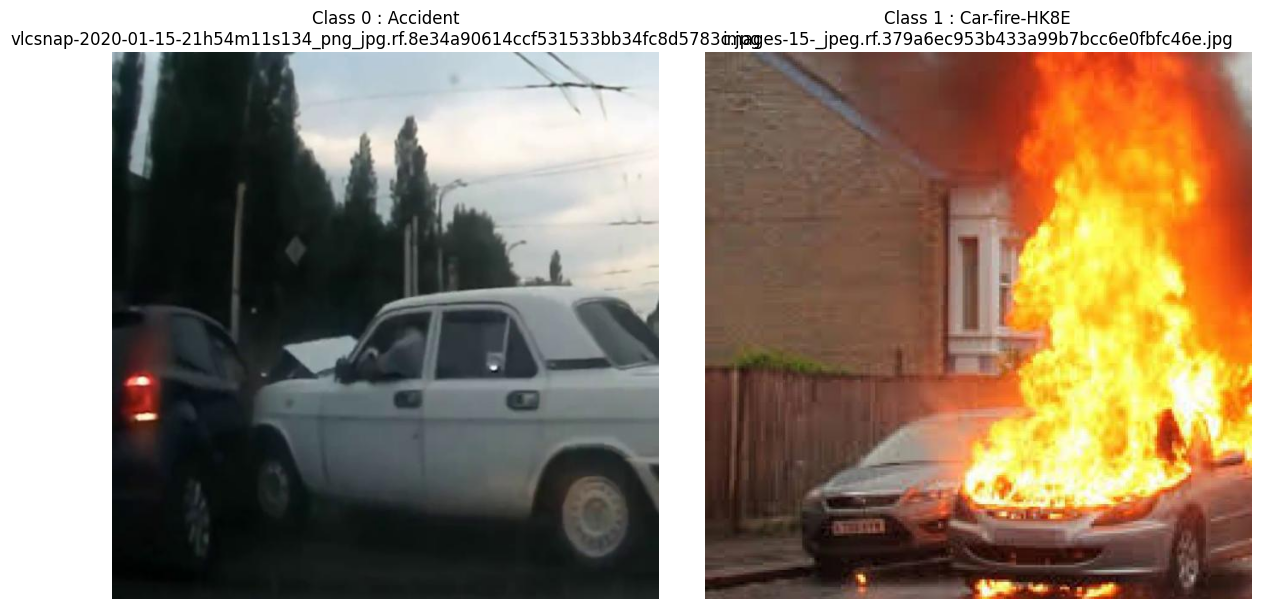

Class 0 example: vlcsnap-2020-01-15-21h54m11s134_png_jpg.rf.8e34a90614ccf531533bb34fc8d5783c.jpg
Class 1 example: images-15-_jpeg.rf.379a6ec953b433a99b7bcc6e0fbfc46e.jpg


In [14]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

BASE = "/kaggle/working/final_combined"
TRAIN_IMAGES = os.path.join(BASE, "train/images")
VAL_IMAGES   = os.path.join(BASE, "val/images")
TRAIN_LABELS = os.path.join(BASE, "train/labels")
VAL_LABELS   = os.path.join(BASE, "val/labels")

dirs = [
    (TRAIN_IMAGES, TRAIN_LABELS),
    (VAL_IMAGES,   VAL_LABELS)
]

class0_candidates = []
class1_candidates = []

for img_dir, lbl_dir in dirs:
    if not os.path.exists(img_dir):
        continue
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lbl_path):
            continue
        with open(lbl_path, 'r') as f:
            content = f.read()
            if ' 0 ' in ' ' + content + ' ':
                class0_candidates.append(os.path.join(img_dir, img_name))
            if ' 1 ' in ' ' + content + ' ':
                class1_candidates.append(os.path.join(img_dir, img_name))


if not class0_candidates or not class1_candidates:
    print("Not enough images with both classes.")
else:
    img0_path = random.choice(class0_candidates)
    img1_path = random.choice(class1_candidates)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    img0 = mpimg.imread(img0_path)
    plt.imshow(img0)
    plt.title(f"Class 0 : Accident\n{os.path.basename(img0_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    img1 = mpimg.imread(img1_path)
    plt.imshow(img1)
    plt.title(f"Class 1 : Car-fire-HK8E\n{os.path.basename(img1_path)}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Class 0 example: {os.path.basename(img0_path)}")
    print(f"Class 1 example: {os.path.basename(img1_path)}")

In [15]:
import os
from collections import Counter

train_labels_dir = "/kaggle/working/final_combined/train/labels"


class_names = {
    0: "Accident",
    1: "Car Fire"
}

if not os.path.exists(train_labels_dir):
    print("Folder not found →", train_labels_dir)

else:
    class_counts = Counter()
    label_files = [f for f in os.listdir(train_labels_dir) if f.lower().endswith('.txt')]
    
    print(f"Found {len(label_files)} label files\n")
    
    for filename in label_files:
        path = os.path.join(train_labels_dir, filename)
        try:
            with open(path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        parts = line.split()
                        if parts and parts[0].isdigit():
                            class_id = int(parts[0])
                            class_counts[class_id] += 1
        except Exception as e:
            print(f"Error in {filename}: {e}")
    
    if class_counts:
        print("Class distribution in training set:\n")
        
        total = sum(class_counts.values())
        
        for cls, count in sorted(class_counts.items()):
            class_name = class_names.get(cls, f"Unknown ({cls})")
            percentage = (count / total) * 100
            print(f"  Class {cls:2d} ({class_name:10s}) : {count:5d} instances  ({percentage:5.2f}%)")
        
        print(f"\nTotal bounding boxes / instances : {total}")
        print(f"Average objects per image        : {total / len(label_files):.2f}")
        
    else:
        print("No valid labels found in any .txt file")

Found 436 label files

Class distribution in training set:

  Class  0 (Accident  ) :   392 instances  (85.22%)
  Class  1 (Car Fire  ) :    68 instances  (14.78%)

Total bounding boxes / instances : 460
Average objects per image        : 1.06


Copying the images and labels into the combined folders

In [16]:
cp /kaggle/input/datasets/pradyu10/data-yaml-fold/data.yaml /kaggle/working/final_combined/

In [17]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")  

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
results = model.train(
    data='/kaggle/working/final_combined/data.yaml',   
    epochs=100,  
    imgsz=640,  
    batch=16,  
    name='accident_fire_detection',  
    device=0
)

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/final_combined/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=accident_fire_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,


image 1/1 /kaggle/input/datasets/pradyu10/test-image/accident.jpg: 384x640 1 Accident, 1 Car-fire-HK8E, 52.7ms
Speed: 3.3ms preprocess, 52.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


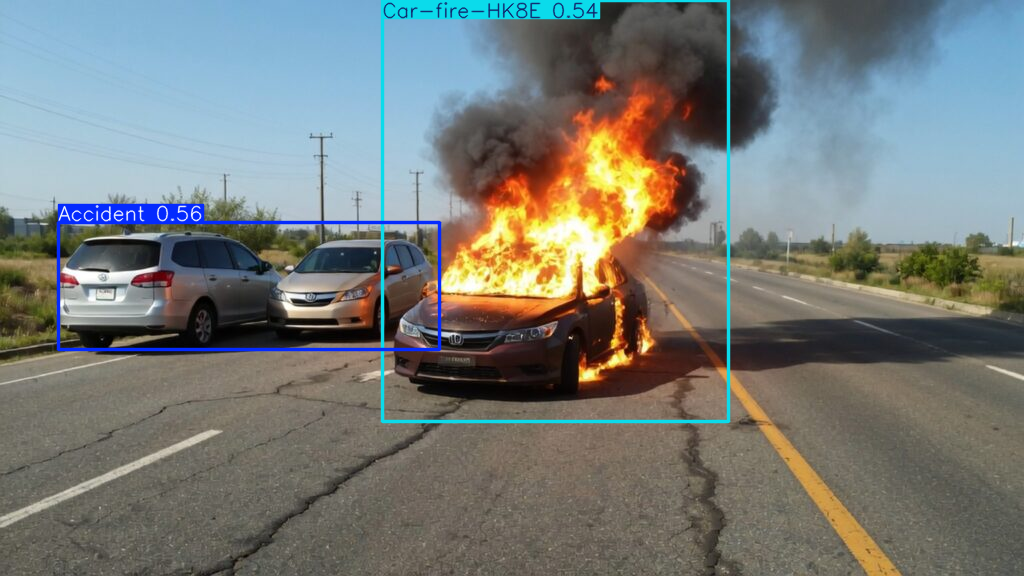

In [19]:
results = model("/kaggle/input/datasets/pradyu10/test-image/accident.jpg")

for result in results:
    result.show()      


image 1/1 /kaggle/input/datasets/pradyu10/test-image2/another_accident.jpg: 480x640 1 Accident, 57.9ms
Speed: 1.8ms preprocess, 57.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


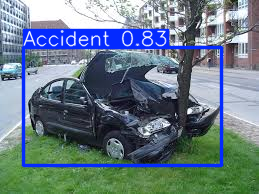

In [20]:
results = model("/kaggle/input/datasets/pradyu10/test-image2/another_accident.jpg")

for result in results:
    result.show()
    result.save()